---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** __장다예__ &nbsp; **학번:** ____20251281____ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. cancer.xlsx의 Data 시트 불러오기
df = pd.read_excel('cancer.xlsx', sheet_name='Data')
df

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
2,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Top dose,15,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
3,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10346,cancer_4524,WOE,NaN,Aminocyclopyrachlor potassium salt,Aminocyclopyrachlor potassium salt,858956-35-1,DTXSID90872814,NaN,Chemical,NaN,...,Cancer classification,Not likely to be carcinogenic to humans,Unitless,"U.S. EPA Office of Pesticide Programs, Chemica...",NaN,[K+].NC1=NC(=NC(C([O-])=O)=C1Cl)C1CC1,Aminocyclopyrachlor potassium salt,858956-35-1|Aminocyclopyrachlor potassium salt...,https://comptox.epa.gov/dashboard/chemical/det...,NaN
10347,cancer_1567,WOE,NaN,"1,6-Dinitropyrene","1,6-Dinitropyrene",42397-64-8,DTXSID90872819,NaN,Chemical,NaN,...,IARC group,2B,Unitless,NaN,http://publications.iarc.fr/64; http://publica...,[O-][N+](=O)C1=CC=C2C=CC3=C(C=CC4=CC=C1C2=C34)...,"1,6-Dinitropyrene","42397-64-8|1,6-Dinitropyrene|Pyrene, 1, 6- din...",https://comptox.epa.gov/dashboard/chemical/det...,NaN
10348,cancer_1568,WOE,NaN,"1,6-Dinitropyrene","1,6-Dinitropyrene",42397-64-8,DTXSID90872819,NaN,Chemical,NaN,...,Listing status,RAHC,Unitless,NaN,https://ntp.niehs.nih.gov/ntp/roc/content/prof...,[O-][N+](=O)C1=CC=C2C=CC3=C(C=CC4=CC=C1C2=C34)...,"1,6-Dinitropyrene","42397-64-8|1,6-Dinitropyrene|Pyrene, 1, 6- din...",https://comptox.epa.gov/dashboard/chemical/det...,NaN
10349,cancer_2718,WOE,NaN,Momfluorothrin,Momfluorothrin,609346-29-4,DTXSID90897320,NaN,Chemical,NaN,...,Cancer classification,Not likely to be carcinogenic to humans,Unitless,"U.S. EPA Office of Pesticide Programs, Chemica...",NaN,COCC1=C(F)C(F)=C(COC(=O)C2C(C=C(C)C#N)C2(C)C)C...,Momfluorothrin,"609346-29-4|Momfluorothrin|4-Methoxymethyl-2,3...",https://comptox.epa.gov/dashboard/chemical/det...,NaN


In [21]:
# 데이터 내 존재하는 종(Species)의 분포 확인
df['Species'].value_counts()

Species
Mouse      3286
Rat        2905
Hamster      20
Name: count, dtype: int64

In [23]:
# 2. 마우스(Mouse) 실험 결과이면서 단일 화학물질(Chemical)만 선택하여 필터링
df_m = df[(df['Species'] == 'Mouse') & (df['Mixture'] == 'Chemical')].copy()
df_m

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
5,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Level of evidence of carcinogenic activity,Inadequate experiment,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
6,cancer_3381,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10302,cancer_3032,In Vivo,NaN,Allyl Glycidyl Ether,Allyl glycidyl ether,106-92-3,DTXSID9039232,NaN,Chemical,Mouse,...,Top dose,10,ppm,TR-376,https://ntp.niehs.nih.gov/publications/reports...,C=CCOCC1CO1,Allyl glycidyl ether,106-92-3|Allyl glycidyl ether|(.+-.)-Allyl gly...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9039232
10303,cancer_7008,In Vivo,NaN,Tenofovir,Tenofovir,147127-20-6,DTXSID9040132,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/1...,C[C@H](CN1C=NC2=C1N=CN=C2N)OCP(O)(O)=O,Tenofovir,147127-20-6|Tenofovir|(((1R)-2-(6-Amino-9H-pur...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040132
10304,cancer_7009,In Vivo,NaN,Tenofovir,Tenofovir,147127-20-6,DTXSID9040132,NaN,Chemical,Mouse,...,Micronucleus,Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/1...,C[C@H](CN1C=NC2=C1N=CN=C2N)OCP(O)(O)=O,Tenofovir,147127-20-6|Tenofovir|(((1R)-2-(6-Amino-9H-pur...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040132
10308,cancer_483,In Vivo,NaN,N-Methylacetoacetamide,N-Methylacetoacetamide,20306-75-6,DTXSID9040138,NaN,Chemical,Mouse,...,Comet assay,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/2...,CNC(=O)CC(C)=O,N-Methylacetoacetamide,20306-75-6|N-Methylacetoacetamide|Acetoacet-mo...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040138


In [24]:
# 마우스 데이터 내에 존재하는 엔드포인트(Endpoint) 종류 및 빈도 확인
df_m['Endpoint'].value_counts()

Endpoint
Top dose                                      1100
Level of evidence of carcinogenic activity    1098
Micronucleus                                   612
POLY-3 lowest dose                             321
Comet assay                                     25
Name: count, dtype: int64

In [25]:
# 3. 발암성 평가 결과에 해당하는 'Level of evidence of carcinogenic activity'를 가진 데이터 추출
df_evi = df_m[df_m['Endpoint'] == 'Level of evidence of carcinogenic activity'].copy()

# 머신러닝 학습에 노이즈를 유발할 수 있는 불확실한 결과(Equivocal, Inadequate, Not tested 등) 제거
valid_responses = ['Clear evidence', 'Some evidence', 'No evidence']
df_evi = df_evi[df_evi['Response'].isin(valid_responses)].copy()
df_evi.shape

(897, 28)

In [26]:
# 필터링된 최종 발암성 응답 값들의 분포 확인
df_evi['Response'].value_counts()

Response
No evidence       516
Clear evidence    320
Some evidence      61
Name: count, dtype: int64

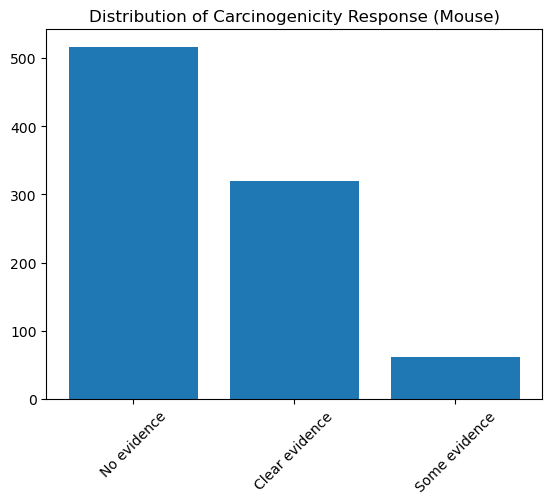

In [27]:
# 응답(Response) 값 분포 시각화
import matplotlib.pyplot as plt
evi_value = df_evi['Response'].value_counts()
plt.bar(evi_value.index, evi_value)
plt.xticks(rotation=45)
plt.title('Distribution of Carcinogenicity Response (Mouse)')
plt.show()

In [28]:
# 데이터 칼럼 확인
df_evi.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Sex', 'Strain', 'Route', 'Level_of_Evidence',
       'Tissue', 'Location', 'Lesion', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name',
       'Synonyms', 'URL_CompTox', 'URL_CEBS'],
      dtype='object')

In [29]:
# 4. 타겟 변수 이진 라벨링 (Active/발암성 있음 = 1, Inactive/발암성 없음 = 0)
df_evi['label'] = 0
df_evi.loc[df_evi['Response'].isin(['Clear evidence', 'Some evidence']), 'label'] = 1

df_total = pd.concat([df_evi])
df_total['label'].value_counts()

label
0    516
1    381
Name: count, dtype: int64

In [30]:
# 데이터 칼럼 확인
df_evi.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Sex', 'Strain', 'Route', 'Level_of_Evidence',
       'Tissue', 'Location', 'Lesion', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name',
       'Synonyms', 'URL_CompTox', 'URL_CEBS', 'label'],
      dtype='object')

In [31]:
# 화합물 이름 리스트 상위 10개 확인
df_total['Chemical_Name'].to_list()[:10]

['Benzyl acetate',
 'Benzyl acetate',
 'Benzyl acetate',
 'Benzyl acetate',
 '4-Chloro-1,3-diaminobenzene',
 '4-Chloro-1,3-diaminobenzene',
 '2-Chloro-1,4-diaminobenzene sulfate (1:1)',
 '2-Chloro-1,4-diaminobenzene sulfate (1:1)',
 '3-Chloro-4-methylaniline',
 '3-Chloro-4-methylaniline']